# Visualization of saved distance matrices


Visualize arrays saved in `/res/sim_res` folder here.

TODO: Implement a SIS model

TODO: Do this in ELFI.


In [2]:
import os
os.getcwd()

os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')

import importlib
import numpy as np
import matplotlib.pyplot as plt

import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


from cluster.scripts.BSI_functions import *

import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions)
from cluster.scripts.BSI_functions import *

import cluster.scripts.SIR_functions
importlib.reload(cluster.scripts.SIR_functions)
from cluster.scripts.SIR_functions import *

incidence = True # If true, use incidence data instead of proportions.

print(os.getcwd())

from cluster.scripts.load_data import *

Loading BSI_functions.py
Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Loading BSI_functions.py
Loading BSI_functions.py
Loading BSI_functions.py
/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli


5.0


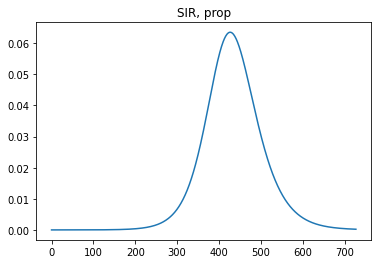

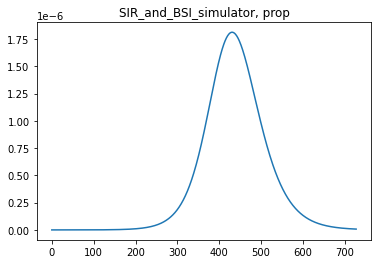

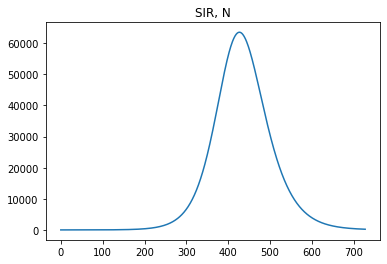

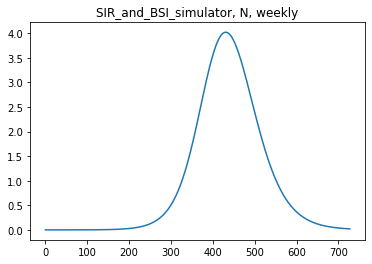

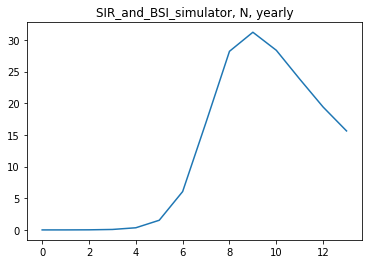

In [3]:
# Sanity checks for SIR_and_BSI_simulator
# NOTE: including I0 for the case with counts instead of proportions will lead to weird results and should not be used.
par1 = 0.09
par2 = 0.06
nt = 728
N = 1000000

print(N*5e-6)
from grid_params import *

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":theta_c, "theta_bsi":theta_bsi, "include_I0":False} # assume load_data loads or_data, norm_data and bsac_data
#sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":is_prop, "is_agg":is_agg,\
            #"time_period":time_period, "reparam":reparam, "batch_size":batch_size, "random_state":random_state}

    
propsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = None, reparam = False, is_prop = True, batch_size=1, random_state = None)
plt.plot(propsir[1][0])
plt.title("SIR, prop")
plt.show()

or_hat = get_OR_hat(or_data = bsi_pars["or_data"], clade = bsi_pars["clade"], dataset = bsi_pars["dataset"], batch_size = 1,random_state = None)
bsi_prop = SIR_and_BSI_simulator(par1, par2, nt, N, bsi_pars, alpha = 0.2, is_prop = True, is_agg = False, time_period = 52, reparam = False, has_or_hat = False, manual_or_hat = None, batch_size = 1, random_state = None)
plt.plot(bsi_prop[0])
plt.title("SIR_and_BSI_simulator, prop")
plt.show()


propsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = None, reparam = False, is_prop = False, batch_size=1, random_state = None)
plt.plot(propsir[1][0])
plt.title("SIR, N")
plt.show()

# very few weekly cases -> makes sense, on a yearly level there are more
# The number varies due to the odds ratio.
bsi_prop = SIR_and_BSI_simulator(par1, par2, nt, N, bsi_pars, alpha = 0.2, is_prop = False, is_agg = False, time_period = 52, reparam = False, has_or_hat = False, manual_or_hat = None, batch_size = 1, random_state = None)
plt.plot(bsi_prop[0])
plt.title("SIR_and_BSI_simulator, N, weekly")
plt.show()

bsi_prop = SIR_and_BSI_simulator(par1, par2, nt, N, bsi_pars, alpha = 0.2, is_prop = False, is_agg = True, time_period = 52, reparam = False, has_or_hat = False, manual_or_hat = None, batch_size = 1, random_state = None)
plt.plot(bsi_prop[0])
plt.title("SIR_and_BSI_simulator, N, yearly")
plt.show()


(728,)


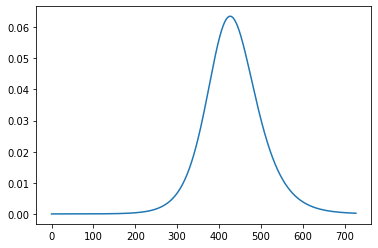

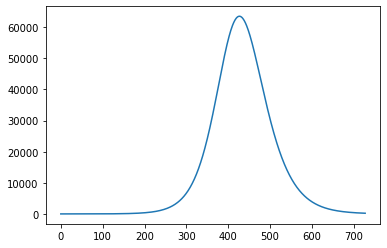

(728,)


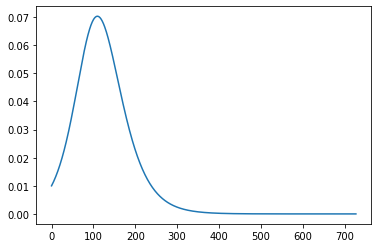

(728,)


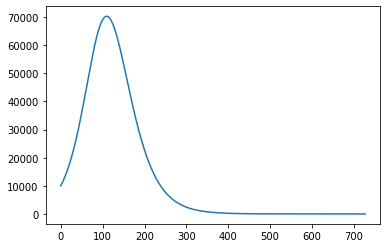

(728,)


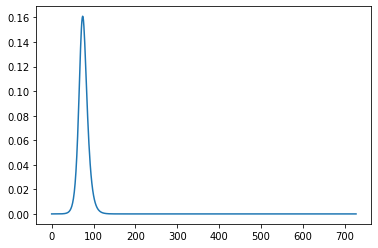

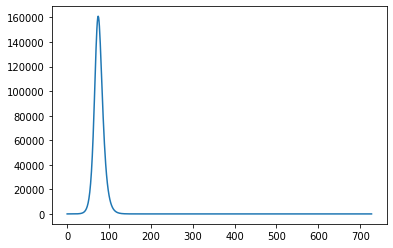

In [4]:
# Sanity check nr 1 propSIR vs nSIR:
# These two sould be of a similar shape
par1 = 0.09
par2 = 0.06
propsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = None, reparam = False, is_prop = True, batch_size=1, random_state = None)[1][0]
print(propsir.shape)
plt.plot(propsir)
plt.show()

nsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = None, reparam = False, is_prop = False, batch_size = 1, random_state = None)[1][0]
plt.plot(nsir)
plt.show()



# Sanity check nr 2: I0, proportional
propsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = 10000, reparam = False, is_prop = True, batch_size=1, random_state = None)[1][0]
print(propsir.shape)
plt.plot(propsir)
plt.show()

# Sanity check: I0, non-proportional
propsir = SIR(par1, par2, nt = 728, N = 1000000, I0 = 10000, reparam = False, is_prop = False, batch_size=1, random_state = None)[1][0]
print(propsir.shape)
plt.plot(propsir)
plt.show()

# Sanity check: reparametrized, proportional vs non-proportional
r_par1 = 0.2
r_par2 = 2

propsir = SIR(r_par1, r_par2, nt = 728, N = 1000000, I0 = None, reparam = True, is_prop = True, batch_size=1, random_state = None)[1][0]
print(propsir.shape)
plt.plot(propsir)
plt.show()

nsir = SIR(r_par1, r_par2, nt = 728, N = 1000000, I0 = None, reparam = True, is_prop = False, batch_size = 1, random_state = None)[1][0]
plt.plot(nsir)
plt.show()


In [108]:
!python3 grid/run_grid.py

/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
Loading BSI_functions.py
Loading BSI_functions.py
Loading BSI_functions.py
Loading BSI_functions.py
{'or_data':    Collection  Clade             Label  ...   upper  pval_f<=5_chi>5  p.adj BH
0        NORM      A          A (NORM)  ...  0.9890           0.0429    0.1287
1        BSAC      A          A (BSAC)  ...  0.6054           0.0003    0.0018
2    Combined      A      A (Combined)  ...  0.8357           0.0077    0.0308
3        NORM      B          B (NORM)  ...  1.2784           0.2585    0.3878
4        BSAC      B          B (BSAC)  ...  1.5721           0.6120    0.6303
5    Combined      B      B (Combined)  ...  1.3346           0.3394    0.4073
6        NORM     C1         C1 (NORM)  ...  6.0389           0.1348    0.2696
7        BSAC     C1         C1 (BSAC)  ...  4.3071           0.6303    0.6303
8    Combined     C1     C1

Loading BSI_functions.py
Results to visualize: res/sim_res/obs_NORM_C2_I0_BSAC_or/sim_params.txt
{'n_weeks': 728, 'pop_size': 1000000, 'is_prop': True, 'is_agg': True, 'time_period': 52, 'reparam': False, 'batch_size': 1, 'random_state': None, 'n_grid': 250, 'output_directory': 'res/sim_res/obs_NORM_C2_I0_2023-09-27_12-42-44', 'clade': 'C2', 'dataset': 'NORM', 'theta_c': 1.0, 'theta_bsi': 1.2490477151025643e-05, 'include_I0': True}
Year
2004    3.895481e-10
2005    3.949891e-10
2006    4.211914e-10
2007    8.428780e-06
2008    7.024155e-06
2009    8.686990e-06
2010    3.070367e-06
2011    5.760377e-06
2012    1.074183e-05
2013    2.123411e-05
2014    1.365658e-05
2015    2.531273e-05
2016    1.518839e-05
2017    1.656741e-05
Name: C2, dtype: float64


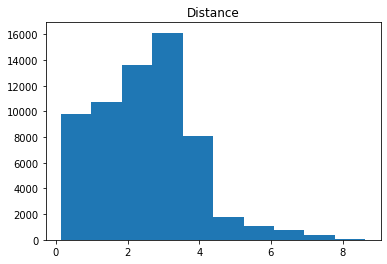

Beta mean: 0.09395980866424089
Gamma mean: 0.06464626506024096
R = mean(beta/gamma): 1.579455483266399
R = median(beta/gamma): 1.3913351004016064


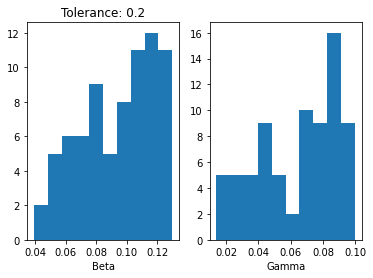

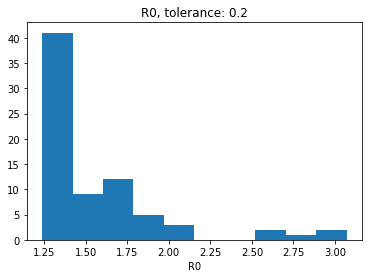

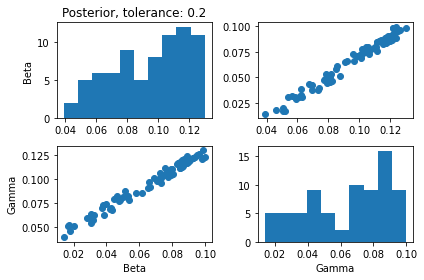

Or mu in plot obs sim: [4.0923]
OR lower: [2.063], OR upper: [8.1176]
[[8.92512066e-10 1.51590303e-09 4.81487161e-09 2.00283539e-08
  8.85750501e-08 3.94414253e-07 1.72289113e-06 6.91074780e-06
  2.13189641e-05 4.12555413e-05 5.14714259e-05 4.96669585e-05
  4.27394093e-05 3.51520175e-05]]
[8.92512066e-10 1.51590303e-09 4.81487161e-09 2.00283539e-08
 8.85750501e-08 3.94414253e-07 1.72289113e-06 6.91074780e-06
 2.13189641e-05 4.12555413e-05 5.14714259e-05 4.96669585e-05
 4.27394093e-05 3.51520175e-05]


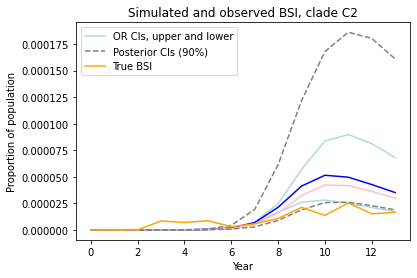

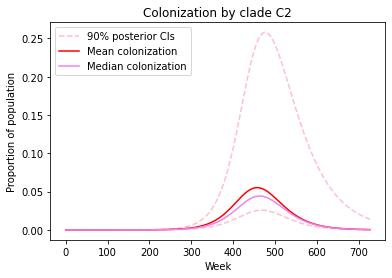

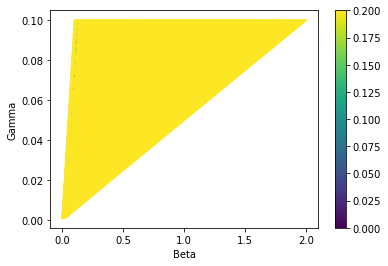

(62500,)


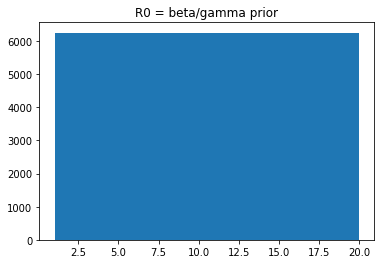

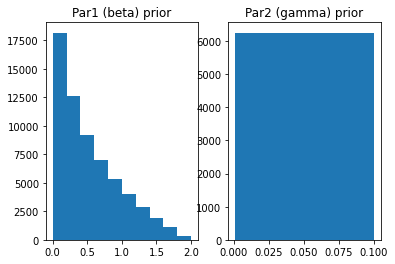

In [21]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

#visualize_results("res/sim_res/time shift/obs_NORM_A_I0_2023-09-05_12-38-21", 0.3)
odir = "res/sim_res/obs_NORM_C2_I0_BSAC_or"
visualize_results(odir, 0.2)
pairs = np.load(os.path.join(odir, "pairs.npy"))


False
False
[3.89548110e+00 3.94989077e-04 1.26357430e+01 4.21438992e+00
 1.05362331e+01 5.79132651e+00 1.53518358e+01 8.64056533e+00
 2.36320218e+01 3.18511701e+01 3.00444681e+01 1.01250923e+01
 2.02511905e+01 2.13009564e+01]


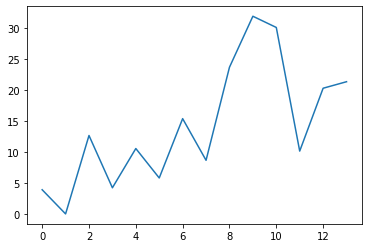

Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000


In [29]:
from grid_params import *

is_prop = False

pairs = get_valid_beta_gamma_pairs(100, 100, min_gamma = 0.001, max_gamma = 0.1, min_R0 = 1.01, max_R0 = 8)
bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":theta_c, "theta_bsi":theta_bsi, "include_I0":include_I0}
sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":is_prop, "is_agg":is_agg,\
            "time_period":time_period, "reparam":reparam, "batch_size":batch_size, "random_state":random_state}
print(sim_pars["is_prop"])
print(sim_pars["reparam"])
bsi_obs = get_incidence_data("data/NORM_incidence.csv", clade = clade, is_prop = is_prop, n_incidence_pop = pop_size).values
print(bsi_obs)

plt.plot(bsi_obs)
plt.show()



dists, summary_dists = get_distance_points(pairs, bsi_obs, sim_pars,\
                                           [BSI_1, BSI_2, BSI_3, BSI_4, BSI_5, BSI_6, BSI_7, BSI_8, BSI_9, BSI_10,\
                                            BSI_11, BSI_12, BSI_13, BSI_14])

plt.hist(dists)
plt.show()

eps = 0.0005
plot_histograms(dists, pairs[:,0], pairs[:,1], eps, par1_label = "Beta", par2_label = "Gamma", xlim = None, save = False, filename = "no_name")

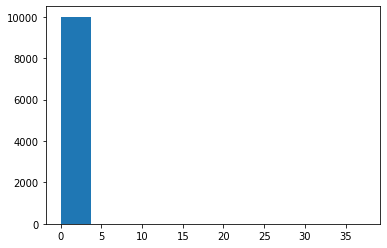

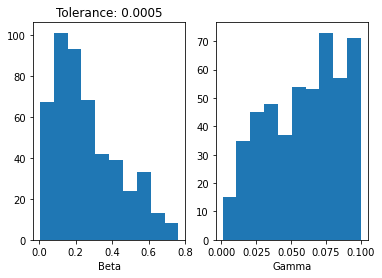

0.00101001 0.001
0.023005490303030302 0.006


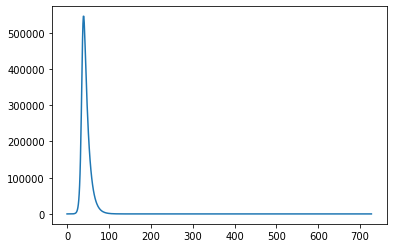

In [26]:
import cluster.scripts.SIR_functions
importlib.reload(cluster.scripts.SIR_functions)
from cluster.scripts.SIR_functions import *

print(pairs[0,0], pairs[1,1])
print(pairs[540,0], pairs[540,1])
SIRsim = SIR(0.56, 0.1, nt = sim_pars["n_weeks"], N = sim_pars["pop_size"], I0 = None,\
             reparam = False, batch_size = 1, random_state = None)[1][0]

plt.plot(SIRsim)
plt.show()

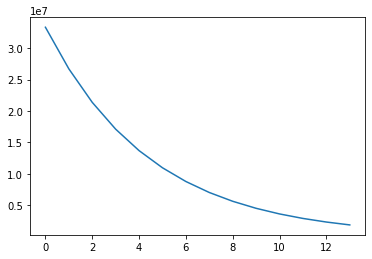

In [28]:
sim_seq = SIR_and_BSI_simulator(par1 = 0.56, par2 = 0.1, nt = sim_pars["n_weeks"], N = sim_pars["pop_size"], bsi_pars = sim_pars["bsi_pars"],\
                                        is_prop = sim_pars["is_prop"], is_agg = sim_pars["is_agg"], time_period = sim_pars["time_period"],\
                                        reparam = sim_pars["reparam"], batch_size = sim_pars["batch_size"], random_state = sim_pars["random_state"])[0]

plt.plot(sim_seq)
plt.show()

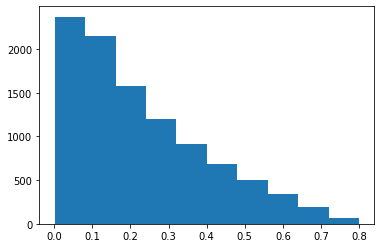

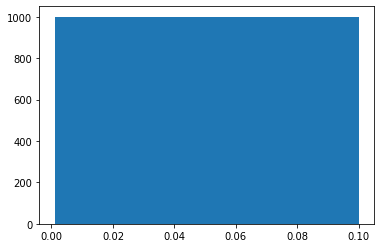

9

In [24]:
plt.hist(pairs[:,0])
plt.show()

plt.hist(pairs[:,1])
plt.show()

BSI_max_t(bsi_obs)

Loading BSI_functions.py
Results to visualize: res/sim_res/obs_NORM_A_I0_2023-09-26_18-41-06/sim_params.txt
Year
2004    3.895481e-10
2005    3.949891e-10
2006    4.211914e-10
2007    8.428780e-06
2008    7.024155e-06
2009    8.686990e-06
2010    3.070367e-06
2011    5.760377e-06
2012    1.074183e-05
2013    2.123411e-05
2014    1.365658e-05
2015    2.531273e-05
2016    1.518839e-05
2017    1.656741e-05
Name: C2, dtype: float64


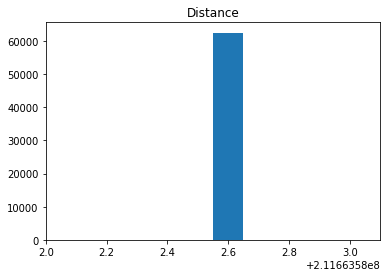

Beta mean: nan
Gamma mean: nan
R = mean(beta/gamma): nan
R = median(beta/gamma): nan


/u/50/ojalaf2/unix/miniconda3/envs/ecoli-elfi/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/u/50/ojalaf2/unix/miniconda3/envs/ecoli-elfi/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


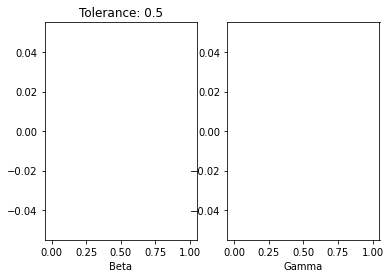

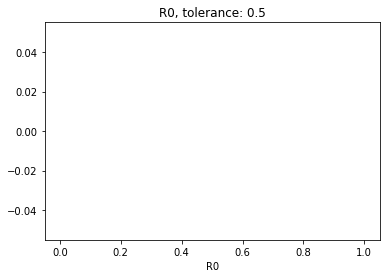

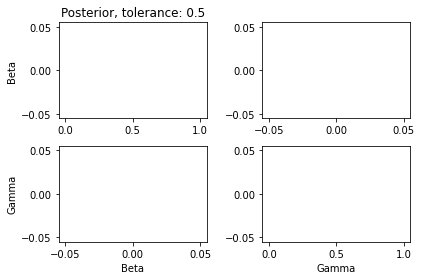

ValueError: 'a' cannot be empty unless no samples are taken

In [10]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

#visualize_results("res/sim_res/time shift/obs_NORM_A_I0_2023-09-05_12-38-21", 0.3)
visualize_results("res/sim_res/obs_NORM_A_I0_2023-09-26_18-41-06", 0.5)

In [8]:
# A new theta_bsi - average yearly proportions divided by 52 to get weekly proportions:

all_prop = 0.0004869351373 + 0.0005292853635 + 0.0005349131215 + 0.0005900145889 + 0.0005584203538 + 0.0005559673451 + 0.0006017919621 +\
0.0006394018344 + 0.0005950972774 + 0.0006768373649 + 0.0007237985505 + 0.0007669757393 + 0.0007897964311 + 0.000811803115 + 0.000881533993
R_bsi = all_prop/15
print(f"R_BSI: {R_bsi}")
theta_bsi = R_bsi/52
print(f"theta_BSI: {theta_bsi}")

#modify_grid_params("grid/grid_params/final_yearly_bsi/", "theta_bsi", theta_bsi)

R_BSI: 0.0006495048118533334
theta_BSI: 1.2490477151025643e-05


In [9]:
import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions)
from cluster.scripts.BSI_functions import *

pairs = np.load("res/sim_res/obs_NORM_A_I0_2023-09-14_11-17-19_BSI_i_BSI_max_t/pairs.npy")
dists = np.load("res/sim_res/obs_NORM_A_I0_2023-09-14_11-17-19_BSI_i_BSI_max_t/dists.npy")
eps = 0.5

acc_pairs = pairs[np.where(pairs < eps)[0], :]

par1_post_mean = np.mean(acc_pairs[:,0])
par2_post_mean = np.mean(acc_pairs[:,1])

print(par1_post_mean, par2_post_mean)


# Visualize uncertainty only associated with the odds ratio:

from cluster.scripts.load_data import *
from grid_params import *

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":theta_c, "theta_bsi":theta_bsi, "include_I0":False} # assume load_data loads or_data, norm_data and bsac_data

or_data.head()
clade = "A"
dataset = "NORM"

df = or_data[or_data["Label"] == f'{clade} ({dataset})']
or_mu = df["OR"].values

or_lower = df["lower"].values
or_upper = df["upper"].values

# deterministic with fixed or_hat values:
mu_sim = SIR_and_BSI_simulator(par1_post_mean, par2_post_mean, nt = 728, N = 1000000, bsi_pars = bsi_pars,\
                      is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                      has_or_hat = True, manual_or_hat = or_mu, batch_size = 1, random_state = None)

lower_sim = SIR_and_BSI_simulator(par1_post_mean, par2_post_mean, nt = 728, N = 1000000, bsi_pars = bsi_pars,\
                      is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                      has_or_hat = True, manual_or_hat = or_lower, batch_size = 1, random_state = None)

upper_sim = SIR_and_BSI_simulator(par1_post_mean, par2_post_mean, nt = 728, N = 1000000, bsi_pars = bsi_pars,\
                      is_prop = True, is_agg = True, time_period = 52, reparam = False,\
                      has_or_hat = True, manual_or_hat = or_upper, batch_size = 1, random_state = None)

print(lower_sim)
print(mu_sim)
print(upper_sim)


Loading BSI_functions.py
0.41618784385827096 0.04523128093772808
[[4.06476081e-11 3.25180864e-11 2.60144692e-11 2.08115753e-11
  1.66492603e-11 1.33194082e-11 1.06555266e-11 8.52442125e-12
  6.81953700e-12 5.45562960e-12 4.36450368e-12 3.49160294e-12
  2.79328236e-12 2.23462588e-12]]
[[6.99360758e-11 5.59488606e-11 4.47590885e-11 3.58072708e-11
  2.86458166e-11 2.29166533e-11 1.83333227e-11 1.46666581e-11
  1.17333265e-11 9.38666120e-12 7.50932896e-12 6.00746317e-12
  4.80597053e-12 3.84477643e-12]]
[[2.50224378e-11 2.00179502e-11 1.60143602e-11 1.28114881e-11
  1.02491905e-11 8.19935241e-12 6.55948193e-12 5.24758554e-12
  4.19806843e-12 3.35845475e-12 2.68676380e-12 2.14941104e-12
  1.71952883e-12 1.37562306e-12]]


Loading BSI_functions.py
Loading BSI_functions.py
Results to visualize: res/sim_res/BSI_vector_and_BSI_max_t/obs_NORM_A_I0_2023-09-14_10-40-07/sim_params.txt
{'n_weeks': 728, 'pop_size': 1000000, 'is_prop': True, 'is_agg': True, 'time_period': 52, 'reparam': False, 'batch_size': 1, 'random_state': None, 'n_grid': 250, 'output_directory': 'res/sim_res/obs_NORM_A_I0_2023-09-14_10-40-07', 'clade': 'A', 'dataset': 'NORM', 'theta_c': 1.0, 'theta_bsi': 1.3382654090384618e-05, 'include_I0': True}
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


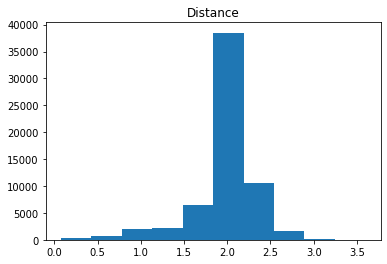

Beta mean: 0.026924716585385318
Gamma mean: 0.01711230442130513
R = mean(beta/gamma): 1.9127669797743008
R = median(beta/gamma): 1.6201301606425704


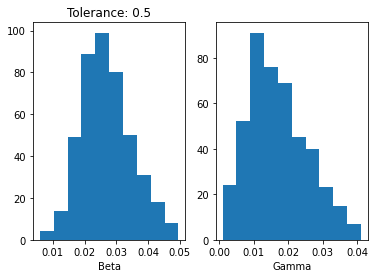

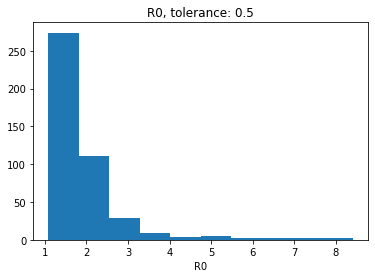

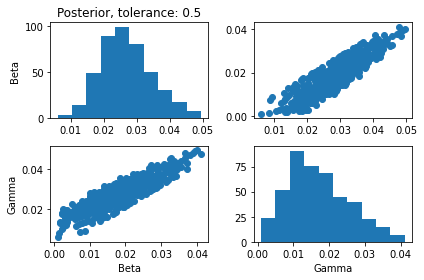

Or mu in plot obs sim: [0.5706]
OR lower: [0.3292], OR upper: [0.989]
[[5.00218578e-06 5.60548876e-06 6.96318804e-06 9.19909858e-06
  1.22842421e-05 1.59020887e-05 1.94459081e-05 2.22345078e-05
  2.38059521e-05 2.40575097e-05 2.31792121e-05 2.14992118e-05
  1.93543789e-05 1.70220291e-05]]
[5.00218578e-06 5.60548876e-06 6.96318804e-06 9.19909858e-06
 1.22842421e-05 1.59020887e-05 1.94459081e-05 2.22345078e-05
 2.38059521e-05 2.40575097e-05 2.31792121e-05 2.14992118e-05
 1.93543789e-05 1.70220291e-05]


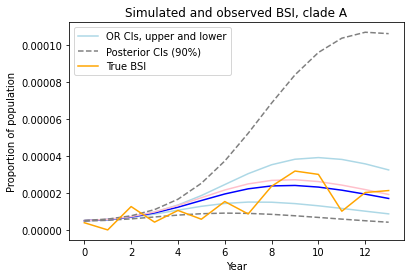

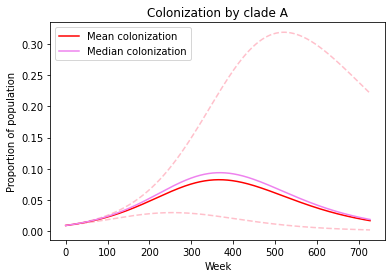

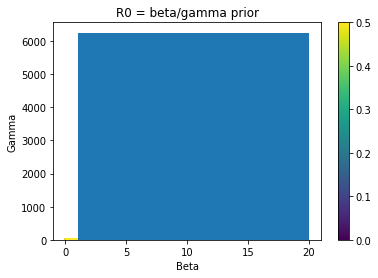

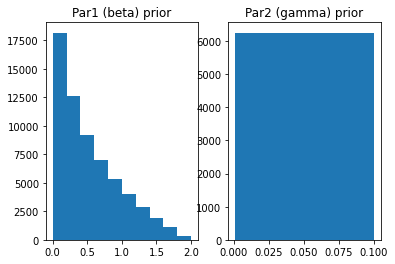

In [59]:
# NORM, clade A

import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions)
from cluster.scripts.BSI_functions import *

#visualize_results("res/sim_res/time shift/obs_NORM_A_I0_2023-09-05_12-38-21", 0.3)
visualize_results("res/sim_res/BSI_vector_and_BSI_max_t/obs_NORM_A_I0_2023-09-14_10-40-07", 0.5)

Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_A_no_I0_2023-09-14_14-38-47/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


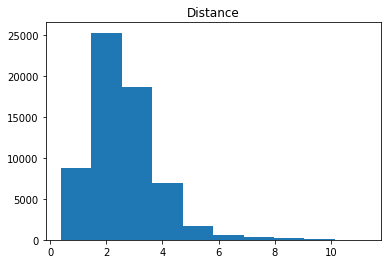

Beta mean: 0.06472351164529073
Gamma mean: 0.03027520608750793
R = mean(beta/gamma): 2.6522166494927077
R = median(beta/gamma): 2.077720281124498


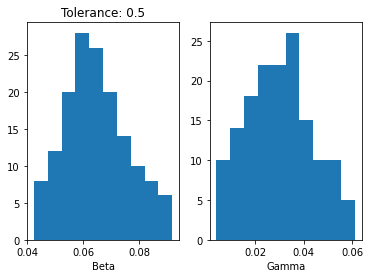

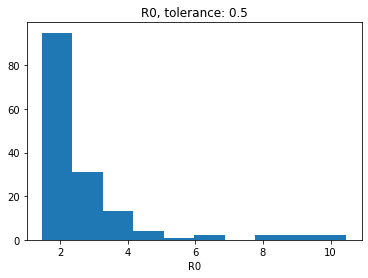

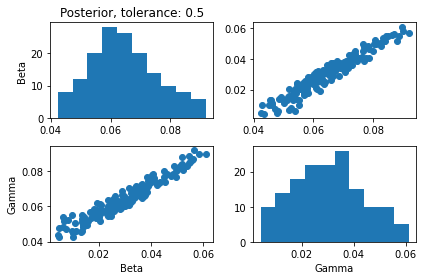

[1.06824704e-09 2.09779254e-09 8.91052550e-09 4.91455602e-08
 2.81523420e-07 1.56143934e-06 7.19782216e-06 1.94948247e-05
 2.81908881e-05 2.88744470e-05 2.56348595e-05 2.14552399e-05
 1.75100131e-05 1.41332301e-05]


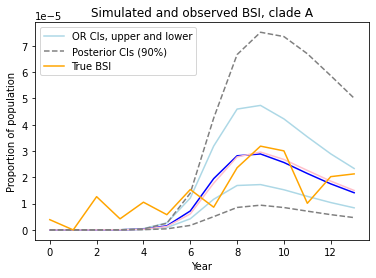

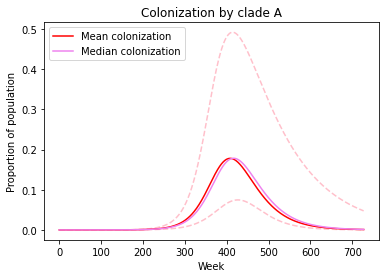

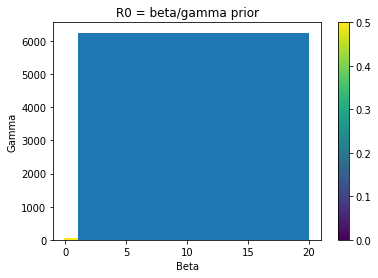

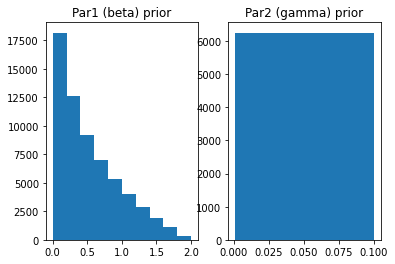

In [10]:
#visualize_results("res/sim_res/time shift/obs_NORM_A_no_I0_2023-09-05_12-57-28", 0.3)
visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_A_no_I0_2023-09-14_14-38-47", 0.5)

Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C2_no_I0_2023-09-14_15-21-15/sim_params.txt
Year
2004    3.895481e-10
2005    3.949891e-10
2006    4.211914e-10
2007    8.428780e-06
2008    7.024155e-06
2009    8.686990e-06
2010    3.070367e-06
2011    5.760377e-06
2012    1.074183e-05
2013    2.123411e-05
2014    1.365658e-05
2015    2.531273e-05
2016    1.518839e-05
2017    1.656741e-05
Name: C2, dtype: float64


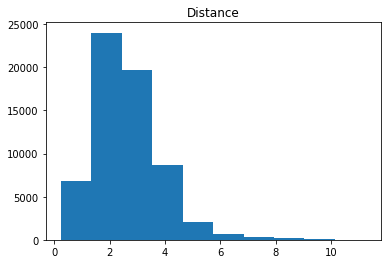

Beta mean: 0.06697532994080942
Gamma mean: 0.040691114457831336
R = mean(beta/gamma): 2.1469943410307897
R = median(beta/gamma): 1.6201301606425706


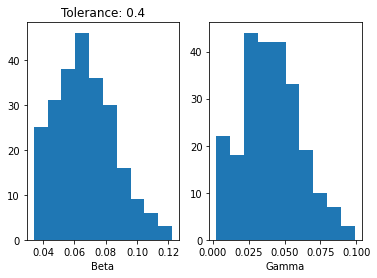

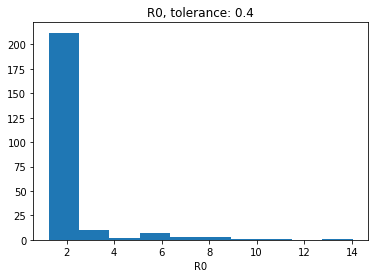

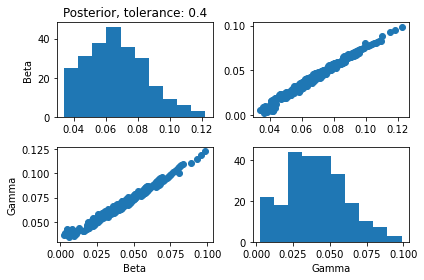

[1.01298337e-09 1.59117711e-09 4.28168818e-09 1.50141936e-08
 5.65706042e-08 2.15447438e-07 8.06241269e-07 2.80412014e-06
 7.88728542e-06 1.49921913e-05 1.91758155e-05 1.91963499e-05
 1.70388576e-05 1.43054711e-05]


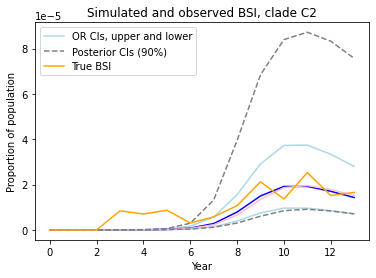

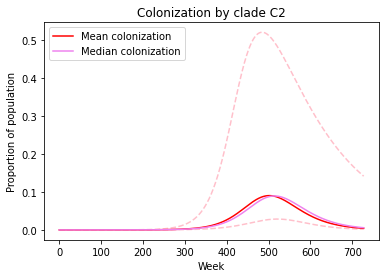

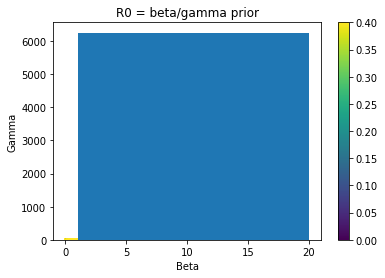

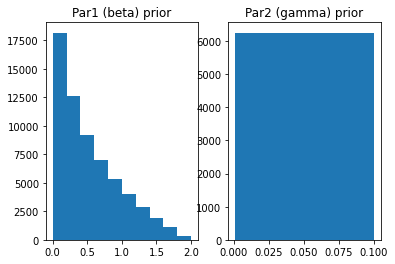

In [13]:
# NORM, clade C2, I0 fix

#visualize_results("res/sim_res/time shift/obs_NORM_C2_I0_2023-09-05_13-16-27", 2.6)



# NORM clade C2,no I0 fix (starts at 0)

visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C2_no_I0_2023-09-14_15-21-15", 0.4)


Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C1_no_I0_2023-09-14_15-27-32/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    4.211914e-06
2007    4.214390e-06
2008    7.024155e-06
2009    1.158265e-05
2010    9.211101e-06
2011    1.440094e-05
2012    8.593462e-06
2013    2.123411e-05
2014    2.185052e-05
2015    2.278146e-05
2016    3.290818e-05
2017    2.603450e-05
Name: C1, dtype: float64


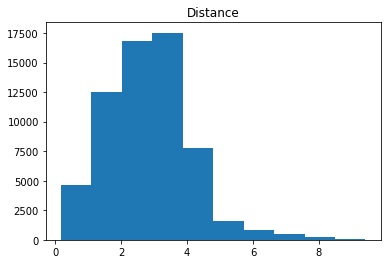

Beta mean: 0.05017878361946704
Gamma mean: 0.03087350882577145
R = mean(beta/gamma): 3.1142696902400067
R = median(beta/gamma): 1.7726602008032128


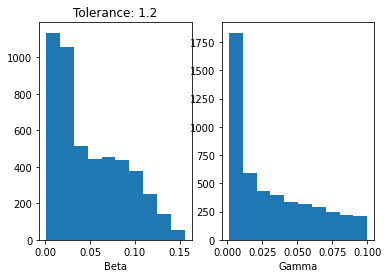

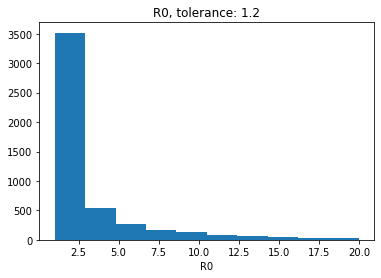

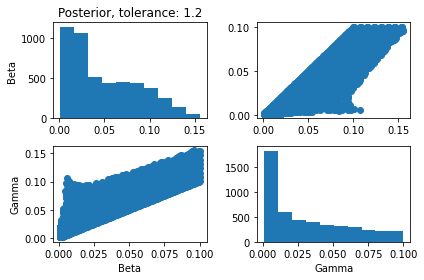

[2.58868522e-09 3.47028589e-09 6.55819606e-09 1.54668701e-08
 3.99842828e-08 1.06518494e-07 2.85955973e-07 7.66245307e-07
 2.02970142e-06 5.21108919e-06 1.24314670e-05 2.56860805e-05
 4.29336485e-05 5.72356524e-05]


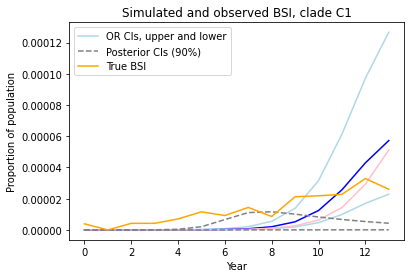

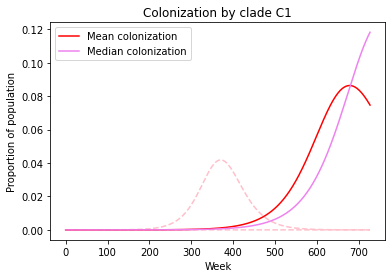

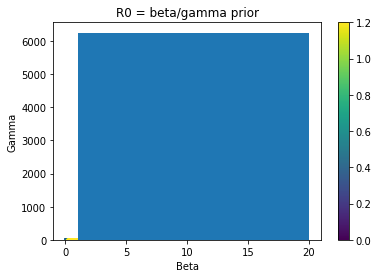

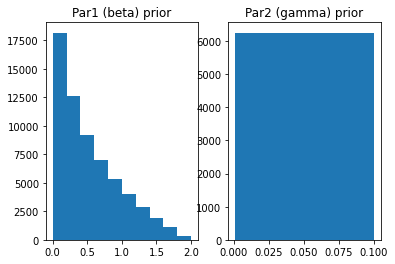

In [22]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


# NORM, clade C1:
visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C1_no_I0_2023-09-14_15-27-32", 1.2)

Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C1_no_I0_2023-09-14_15-27-32/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    4.211914e-06
2007    4.214390e-06
2008    7.024155e-06
2009    1.158265e-05
2010    9.211101e-06
2011    1.440094e-05
2012    8.593462e-06
2013    2.123411e-05
2014    2.185052e-05
2015    2.278146e-05
2016    3.290818e-05
2017    2.603450e-05
Name: C1, dtype: float64


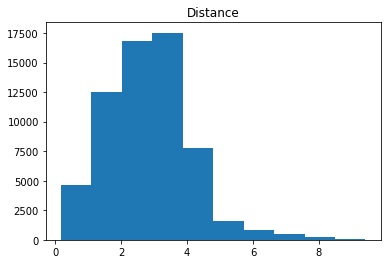

Beta mean: 0.2526772323112485
Gamma mean: 0.049934420606324637
R = mean(beta/gamma): 5.3408361348861115
R = median(beta/gamma): 3.908080763052209


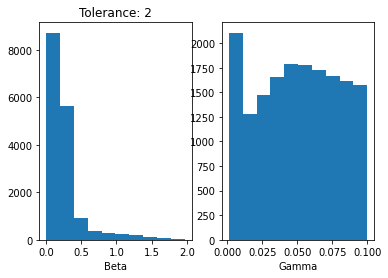

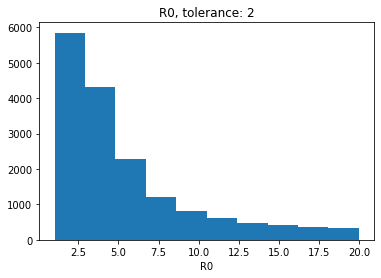

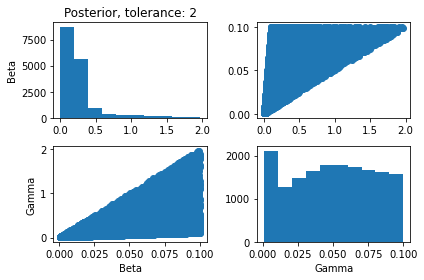

[2.10113955e-06 6.22518670e-05 7.33766269e-05 6.07634077e-05
 4.87672615e-05 3.90255533e-05 3.12213229e-05 2.49771243e-05
 1.99817044e-05 1.59853639e-05 1.27882911e-05 1.02306329e-05
 8.18450634e-06 6.54760507e-06]


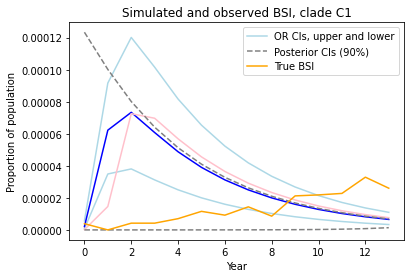

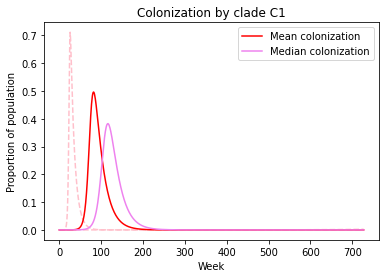

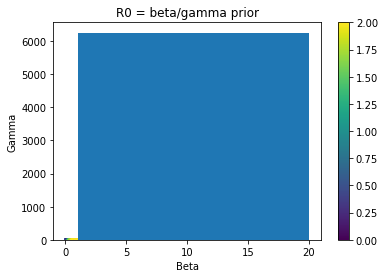

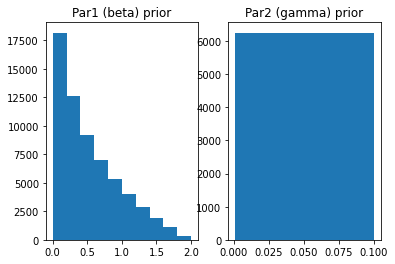

In [23]:
# NORM, clade C1, no I0:
visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_C1_no_I0_2023-09-14_15-27-32", 2)

Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_B_I0_2023-09-14_14-16-04/sim_params.txt
Year
2004    0.000012
2005    0.000024
2006    0.000017
2007    0.000008
2008    0.000004
2009    0.000020
2010    0.000012
2011    0.000014
2012    0.000009
2013    0.000013
2014    0.000011
2015    0.000018
2016    0.000018
2017    0.000024
Name: B, dtype: float64


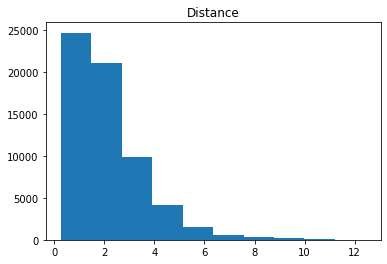

Beta mean: 0.3712555966432954
Gamma mean: 0.06445643996241075
R = mean(beta/gamma): 5.582484162007751
R = median(beta/gamma): 2.4590453815261046


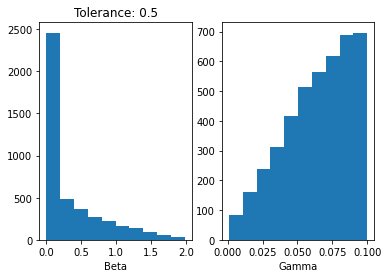

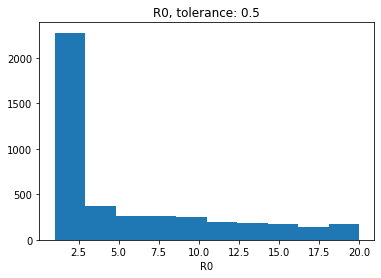

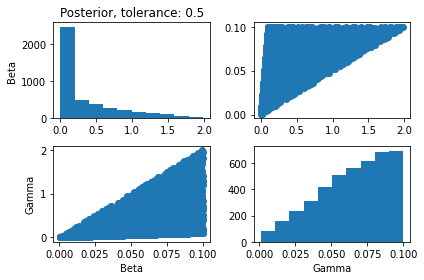

[1.52084827e-04 1.24199331e-04 9.94413821e-05 7.95557793e-05
 6.36447107e-05 5.09157714e-05 4.07326172e-05 3.25860938e-05
 2.60688750e-05 2.08551000e-05 1.66840800e-05 1.33472640e-05
 1.06778112e-05 8.54224897e-06]


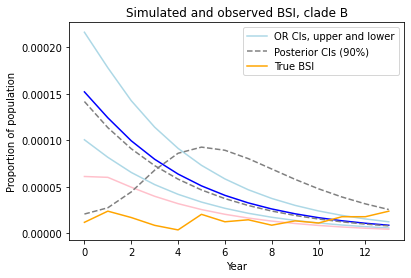

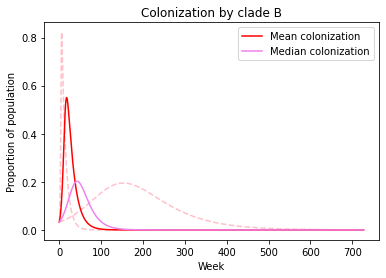

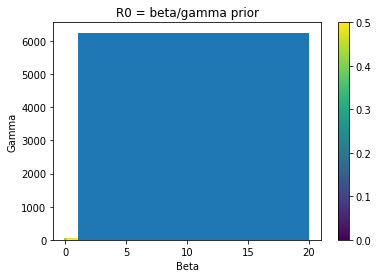

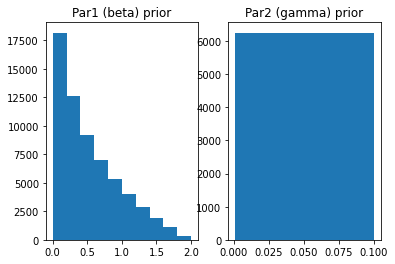

In [27]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


# NORM, clade B:
visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_B_I0_2023-09-14_14-16-04", 0.5)

Results to visualize: res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_B_no_I0_2023-09-14_14-39-02/sim_params.txt
Year
2004    0.000012
2005    0.000024
2006    0.000017
2007    0.000008
2008    0.000004
2009    0.000020
2010    0.000012
2011    0.000014
2012    0.000009
2013    0.000013
2014    0.000011
2015    0.000018
2016    0.000018
2017    0.000024
Name: B, dtype: float64


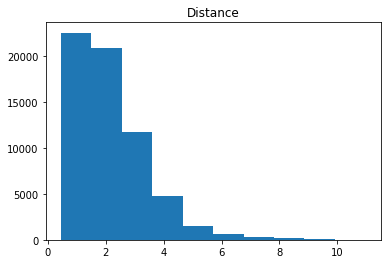

Beta mean: 0.3335447301428053
Gamma mean: 0.06991643445662853
R = mean(beta/gamma): 5.495306838201391
R = median(beta/gamma): 4.518200923694779


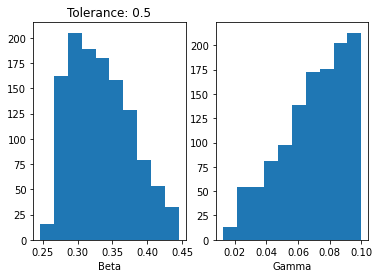

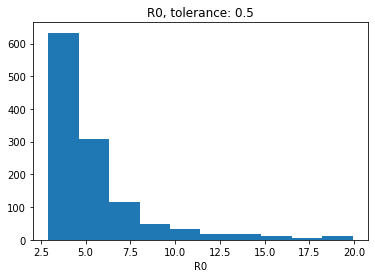

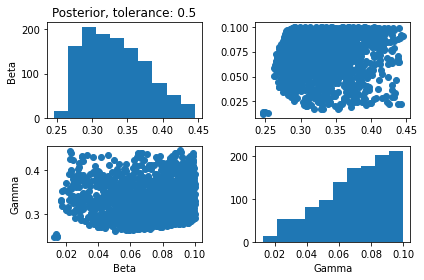

[6.47238383e-06 3.25254867e-05 2.72799968e-05 2.18568669e-05
 1.74863532e-05 1.39891050e-05 1.11912846e-05 8.95302771e-06
 7.16242217e-06 5.72993774e-06 4.58395019e-06 3.66716015e-06
 2.93372812e-06 2.34698250e-06]


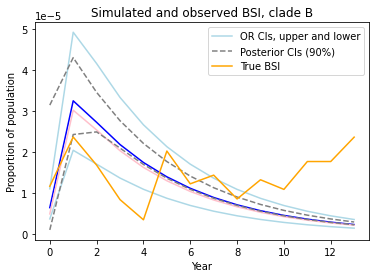

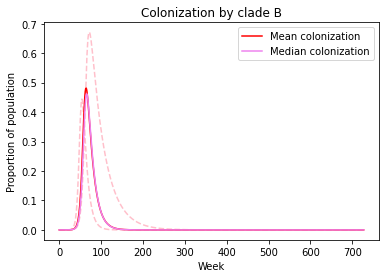

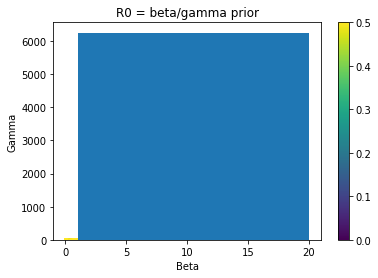

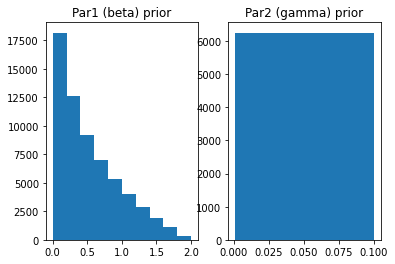

In [29]:
# NORM, clade B, no I0:
visualize_results("res/sim_res/BSI_i_and_BSI_max_t/obs_NORM_B_no_I0_2023-09-14_14-39-02", 0.5)